# Text Mining Project Work (Team 4)

**Cross-Domain Opinion Mining on Multi-Source Reviews with Machine Learning Models and BERT**

_Prof. Gianluca Moro, Prof. Giacomo Frisoni – DISI, University of Bologna_

name.surname@unibo.it


**Bologna Business School** - Alma Mater Studiorum Università di Bologna

## Instructions
- 🤝 The provided exercises must be collectively executed by the students of **Team 4**.
- 🚩 At the end, the file must contain all the required results (as **code cell outputs**) along with all the **commands necessary to reproduce them**.
- 💬 **All choices made during the implementation must be thoroughly commented on**. Students should clearly explain the inner workings of their solutions and justify their approaches. The documentation quality must be on par with the notebooks tackled during lessons. Feel free to add Markdown cells for discussions.
- 📚 **You are allowed to consult the teaching material, search the Web for quick reference, and use LLMs**.
- ⛔ **It is strictly forbidden to communicate with other teams**. If you need clarification about the exercises, ask the teacher directly.
- 📊 **Each exercise has a specific score value**, as indicated in brackets *[X points]*. Your final score will be based on:
    - **Correctness of the Output** (Does the code produce the expected results?)
    - **Quality of the Code** (Is the code efficient, clean, well-structured, and readable?)
    - **Documentation and Justification** (Are choices clearly explained? Is the implementation well-commented and easy to follow?)

---

- ⏰ The **submission deadline** is **March 20th, 2026 at 23:59 (UTC+1)**.
- 📨 When the work is complete—any time before the deadline—**one team member must send the notebook file** (.ipynb extension) **via email to the lab teacher** (giacomo.frisoni@unibo.it). The email subject must be: "**[BBS Teamwork] Team 4**". All other team members must be included in CC in the email.
- ⚖️ Please note that no separate discussion or presentation is planned for this teamwork. The project will receive a **collective assessment**, meaning that all members of the team will receive the same mark. **This evaluation will be complemented and mediated through the individual exam (the theory quiz)**, which will contribute to determining the final assessment.

## **Setup**

Run the following to download the necessary files.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

random_state=42

In [ ]:
import os
from urllib.request import urlretrieve

In [ ]:
def download(file, url):
    if not os.path.exists(file):
        urlretrieve(url, file)

In [ ]:
download("Gift_Cards.json.gz", "https://www.dropbox.com/s/c87cjds263jt3sb/Gift_Cards.json.gz?dl=1")
download("Magazine_Subscriptions.json.gz", "https://www.dropbox.com/s/g6om8q8c8pvirw8/Magazine_Subscriptions.json.gz?dl=1")

## **WandB**
### Login to WandB and check if WandB is installed and if not installed install WandDB

### Below is the link for the WandB project where the runs can be tracked

https://wandb.ai/sukhdeepsinghsaini-bologna-business-school/cross-domain-opinion-mining

In [ ]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: sukhdeepsinghsaini (sukhdeepsinghsaini-bologna-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
%pip install wandb

## **Task 1**: Load Datasets

### ──Step 1: Amazon reviews dataset (Reviews_A) ──

In [ ]:
#Amazon reviews
df_A = pd.read_json("Gift_Cards.json.gz", lines=True, compression="gzip")
df_A = df_A.reset_index(drop=True)

# Sample of 100.000 random registers
reviews_A = df_A.sample(n=100000, random_state=random_state)

reviews_A.head().sort_index(ascending=True)



,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
2495,5,NaN,True,"05 26, 2014",A2BWP68V8GPLZA,B004KNWX6C,NaN,Terese Bedard,I very much like the print-at-home Amazon gift...,Gift Cards - easy and convenient,1401062400,NaN
39765,5,NaN,True,"01 18, 2013",A274I7QL4K9LJ1,B0062ONLI6,NaN,Louis H. Goetz Sr.,The gift card was printed on line and we found...,As requested,1358467200,NaN
65221,5,NaN,True,"10 17, 2017",A3GKHR97RTKO49,B00AR51Y5I,NaN,Jucy,Good,Five Stars,1508198400,NaN
83758,3,NaN,True,"08 26, 2013",A2ZVB7VWCR7NZC,B00CRQ47WC,NaN,Michael,Not much to really say about this other than i...,gift card,1377475200,NaN
135602,5,NaN,True,"09 14, 2016",A1HGHX5WY3TZI0,B01G44QKQI,NaN,John,Ok,Five Stars,1473811200,NaN


In [ ]:
reviews_A.shape

(100000, 12)

### ── Step 2: Magazine reviews Dataset (Reviews_B) ──

In [ ]:
#Magazine file
df_B = pd.read_json("Magazine_Subscriptions.json.gz", lines=True, compression="gzip")
df_B = df_B.reset_index(drop=True)

# Sample of 50.000 random registers
reviews_B = df_B.sample(n=50000, random_state= random_state)

reviews_B.head().sort_index(ascending=True)

,overall,vote,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,style,image
11529,4,4,False,"09 25, 2009",A1Z82LZ6G6W1ZN,B00005N7SV,R. Sak,Got this as a surprise for my boyfriend who is...,Nice Photography,1253836800,{'Format:': ' Print Magazine'},NaN
47529,5,3,False,"02 5, 2011",A13N4V5QXY59JO,B000FTJ7JQ,bellavs84,Believe me when I tell you that I read every c...,Great for young chefs!,1296864000,{'Format:': ' Print Magazine'},NaN
53101,4,NaN,True,"10 8, 2014",A3EYZMUQC80QH1,B000IMVNQU,Pparksca,First time reader of The Atlantic & I was deli...,This soup is good!,1412726400,{'Format:': ' Kindle Edition'},NaN
62779,4,79,False,"11 28, 2010",A1T4G3TB1ANWN4,B001E547FE,E. Andrews,The stated age range for this magazine is 8 an...,Better for older girls,1290902400,NaN,NaN
70238,3,2,True,"12 29, 2013",A3BBRD1LARRAFW,B00F8LWD0G,Danielle,The magazine does not have much material. The...,Not much material,1388275200,{'Format:': ' Print Magazine'},NaN


In [ ]:
reviews_B.shape

(50000, 12)

## **Task 2:** Understand the datasets

### ──Step 1: Total number of reviews  ──

In [ ]:
count_reviews= pd.DataFrame({
    'Dataset': ['Amazon','Magazine'],
    'Total_rows': [len(reviews_A), len(reviews_B)],
    'Total_reviews': [reviews_A['reviewText'].count(), reviews_B['reviewText'].count()]
    })
count_reviews


,Dataset,Total_rows,Total_reviews
0,Amazon,100000,99888
1,Magazine,50000,49985


### ──Step 2: first 10 rows Reviews_A  ──

In [ ]:
reviews_A.head(10)

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
83758,3,NaN,True,"08 26, 2013",A2ZVB7VWCR7NZC,B00CRQ47WC,NaN,Michael,Not much to really say about this other than i...,gift card,1377475200,NaN
135602,5,NaN,True,"09 14, 2016",A1HGHX5WY3TZI0,B01G44QKQI,NaN,John,Ok,Five Stars,1473811200,NaN
65221,5,NaN,True,"10 17, 2017",A3GKHR97RTKO49,B00AR51Y5I,NaN,Jucy,Good,Five Stars,1508198400,NaN
39765,5,NaN,True,"01 18, 2013",A274I7QL4K9LJ1,B0062ONLI6,NaN,Louis H. Goetz Sr.,The gift card was printed on line and we found...,As requested,1358467200,NaN
2495,5,NaN,True,"05 26, 2014",A2BWP68V8GPLZA,B004KNWX6C,NaN,Terese Bedard,I very much like the print-at-home Amazon gift...,Gift Cards - easy and convenient,1401062400,NaN
25749,5,NaN,True,"01 26, 2016",AKU1WSGF91K64,B004Q7CK9M,{'Gift Amount:': ' 15'},Pepper,I bought this as a Christmas gift because I'm ...,The Best Gift Inside the Perfect Card,1453766400,NaN
136036,5,NaN,True,"05 21, 2018",A379S873D06FG,B01H5PPJT4,NaN,CriticallyBoard,Excellent and timely manner.,Five Stars,1526860800,NaN
48763,5,NaN,True,"10 4, 2014",A2T5MPRN6Y1L39,B007V6ETXA,NaN,Leonardo,EXCELENT,Five Stars,1412380800,NaN
57031,2,NaN,True,"01 27, 2017",A2TYZA9PL1OBTP,B0091JL3OI,{'Gift Amount:': ' 0'},Wisconsins1&amp;Only,"Well, I ordered 3 of these all at different va...",How Much?,1485475200,NaN
98620,5,NaN,True,"11 24, 2014",A26CL3XVUSMEMK,B00H5BMH44,NaN,kim hee yeon,Good~!^^,Five Stars,1416787200,NaN


### ──Step 3: first 10 rows Reviews_B ──

In [ ]:
# 10 first rows for dataser reviews_B
reviews_B.head(10)

,overall,vote,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,style,image
70238,3,2,True,"12 29, 2013",A3BBRD1LARRAFW,B00F8LWD0G,Danielle,The magazine does not have much material. The...,Not much material,1388275200,{'Format:': ' Print Magazine'},NaN
47529,5,3,False,"02 5, 2011",A13N4V5QXY59JO,B000FTJ7JQ,bellavs84,Believe me when I tell you that I read every c...,Great for young chefs!,1296864000,{'Format:': ' Print Magazine'},NaN
62779,4,79,False,"11 28, 2010",A1T4G3TB1ANWN4,B001E547FE,E. Andrews,The stated age range for this magazine is 8 an...,Better for older girls,1290902400,NaN,NaN
53101,4,NaN,True,"10 8, 2014",A3EYZMUQC80QH1,B000IMVNQU,Pparksca,First time reader of The Atlantic & I was deli...,This soup is good!,1412726400,{'Format:': ' Kindle Edition'},NaN
11529,4,4,False,"09 25, 2009",A1Z82LZ6G6W1ZN,B00005N7SV,R. Sak,Got this as a surprise for my boyfriend who is...,Nice Photography,1253836800,{'Format:': ' Print Magazine'},NaN
18591,5,NaN,True,"09 30, 2014",AR89B0B7ZJK7I,B00005NIOW,P AG,great magazine.,Five Stars,1412035200,{'Format:': ' Print Magazine'},NaN
40853,4,NaN,True,"05 17, 2014",A1MLO08MWFGB8P,B00008DP07,museon,I used to read Scientific American before they...,"Less science, but interesting",1400284800,NaN,NaN
50266,4,NaN,True,"01 13, 2015",A28UH0ED1NMA5L,B000IJ84F6,Observe_the_cat!,I'm an old lady living in a young(ish) woman's...,Great deal,1421107200,NaN,NaN
46847,5,4,True,"10 22, 2012",A223S314MT5T08,B000EU1H76,Dany,"I loved this magazine, it gave me so really ni...",Loved it!,1350864000,NaN,NaN
67291,5,NaN,False,"04 9, 2015",A3R1KVH661LTGE,B005DNCFP2,jwko,"Renewed last month for 2 years, $15! Received ...",Good magazine - just too expensive here. Read ...,1428537600,{'Format:': ' Print Magazine'},NaN


### ──Step 4: Labels distribution  ──

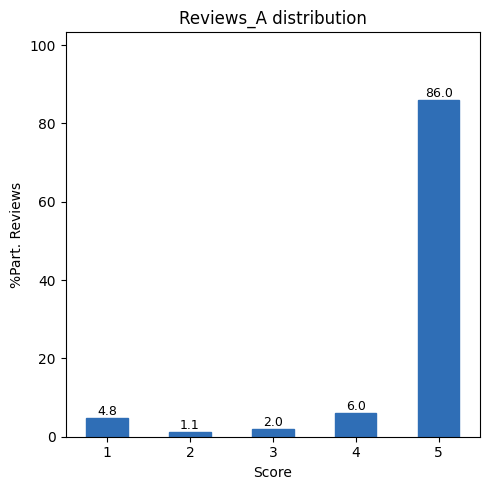

In [119]:
counts = reviews_A['overall'].value_counts(normalize=True).sort_index()*100
ax = counts.plot(kind='bar', title="Reviews_A distribution", figsize=(5, 5), color='#2F6EB6', edgecolor='#2F6EB6')

plt.xticks(rotation=0)
plt.ylim(0, counts.max() * 1.2)
plt.xlabel('Score', fontsize=10)
plt.ylabel('%Part. Reviews', fontsize=10)

# Labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Note:** The number of reviews with a 5 start rating is more than 80% which means the dataset is unbalanced

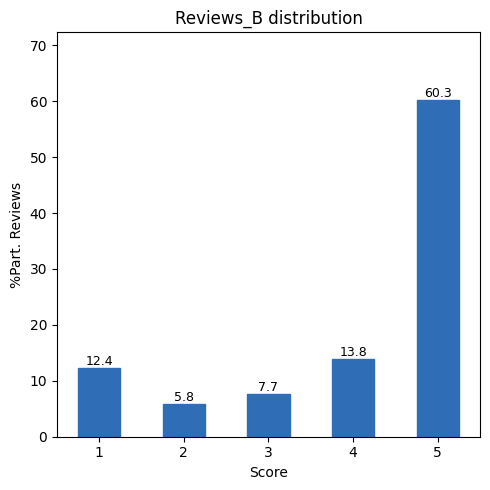

In [118]:
counts = reviews_B['overall'].value_counts(normalize=True).sort_index()*100
ax = counts.plot(kind='bar', title="Reviews_B distribution", figsize=(5, 5), color='#2F6EB6', edgecolor='#2F6EB6')

plt.xticks(rotation=0)
plt.ylim(0, counts.max() * 1.2)
plt.xlabel('Score', fontsize=10)
plt.ylabel('%Part. Reviews', fontsize=10)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

##### **Note:** The number of reviews with a 5 start rating is more than 60% which means the dataset is unbalanced

## **Task 3:** Balance classes from Reviews_A


In [ ]:
# Undersampling to reduce the Imbalanced 5 start reviews in Reviews_A dataset
# we did undersampling as overall had high number of reviews

min_size = reviews_A['overall'].value_counts().min()

balanced_reviews_A = reviews_A.groupby('overall', group_keys=False).sample(
    n=min_size,
    random_state=random_state
).reset_index(drop=True)

balanced_reviews_A['overall'].value_counts()


,count
overall,
1,1115
2,1115
3,1115
4,1115
5,1115


## **Task 4:** Preprocess A

### ──Step 1: New dataset with Reviews_A  ──

In [ ]:
new_reviews_A = balanced_reviews_A[['overall','reviewText']]
new_reviews_A


,overall,reviewText
0,1,I tried for 3 days to use this gift card. Wasn...
1,1,Would not recommend this card. The first card...
2,1,It didn't arrive in time and not eligible to r...
3,1,The bad thing about the amazon gift cards is t...
4,1,Half of employees are not trained on how to us...
...,...,...
5570,5,My grandson thanks you. He loved the gift
5571,5,How can you go wrong
5572,5,Great selection of gift cards on Amazon!
5573,5,"It works perfectly, I've bought it several tim..."


### ──Step 2: Removing 3 starts rating ──

In [ ]:
new_reviews_A = new_reviews_A[new_reviews_A['overall'] != 3][['overall', 'reviewText']]
new_reviews_A



,overall,reviewText
0,1,I tried for 3 days to use this gift card. Wasn...
1,1,Would not recommend this card. The first card...
2,1,It didn't arrive in time and not eligible to r...
3,1,The bad thing about the amazon gift cards is t...
4,1,Half of employees are not trained on how to us...
...,...,...
5570,5,My grandson thanks you. He loved the gift
5571,5,How can you go wrong
5572,5,Great selection of gift cards on Amazon!
5573,5,"It works perfectly, I've bought it several tim..."


### ──Step 3: New label column *Sentiment* ──

In [ ]:
#Add a new label column to classify the scores in "pos" and "neg" labels
new_reviews_A['sentiment'] = np.where(new_reviews_A['overall'] >= 4, 'pos',
                             np.where(new_reviews_A['overall'] <= 2, 'neg', 'neutral'))
new_reviews_A

,overall,reviewText,sentiment
0,1,I tried for 3 days to use this gift card. Wasn...,neg
1,1,Would not recommend this card. The first card...,neg
2,1,It didn't arrive in time and not eligible to r...,neg
3,1,The bad thing about the amazon gift cards is t...,neg
4,1,Half of employees are not trained on how to us...,neg
...,...,...,...
5570,5,My grandson thanks you. He loved the gift,pos
5571,5,How can you go wrong,pos
5572,5,Great selection of gift cards on Amazon!,pos
5573,5,"It works perfectly, I've bought it several tim...",pos


## <h2 style="color:#D35400">**Task 5:** Split A</h2>
<p style="font-size:14px; line-height:2">
<span style="color:#2C3E50">Split the preprocessed dataset A randomly into train-eval-test splits using a <b style="color:#8E44AD">80-10-10</b> ratio.</span><br>
<span style="color:#2C3E50"><b style="color:#E67E22">Stratification</b> ensures that both the training and test sets contain a proportional mix of all class labels.</span>
</p>

###<h4 style="color:#2E86C1">── Defining Features and Target ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#8E44AD"><b>X</b></span> <span style="color:#2C3E50">→ The text column used as input features for the model</span><br>
<span style="color:#E67E22"><b>y</b></span> <span style="color:#2C3E50">→ The label/target column the model will learn to predict</span>
</p>

In [ ]:
X = new_reviews_A["reviewText"]
y = new_reviews_A["sentiment"]

### <h4 style="color:#2E86C1">── Step 1: Handling Missing Values ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#2C3E50">TF-IDF cannot process <b style="color:#E74C3C">NaN (missing)</b> values and throws a ValueError if any are present.</span><br>
<span style="color:#2C3E50">Dropping rows with null text ensures clean input before vectorization.</span>
</p>

In [ ]:
print(X.isna().sum())

3


In [ ]:
mask = X.notna()
X = X[mask]
y = y[mask]

### <h4 style="color:#2E86C1">── Step 2: Splitting Train, Validation and Test Sets ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#8E44AD"><b>First Split</b></span> <span style="color:#2C3E50">→ 80% Training set, 20% Temp set (validation + test)</span><br>
<span style="color:#E67E22"><b>Second Split</b></span> <span style="color:#2C3E50">→ 20% of Temp, Validation = 10% and Test = 10% </span><br>
<span style="color:#27AE60"><b>Stratify = y</b></span> <span style="color:#2C3E50">→ Maintains class distribution equally across all three splits</span>
</p>

In [ ]:
temp_size_value = 0.2
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = temp_size_value,
    random_state = random_state,
    stratify = y
)

#Spliting temp_set=20% into validation_set=10% and test_set=10%
temp_size_value = 0.5
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = temp_size_value,
    random_state = random_state,
    stratify = y_temp
)

print(f"Original shape:{X.shape} Train shape:{X_train.shape} Val shape:{X_val.shape} test shape:{X_test.shape}")

Original shape:(4457,) Train shape:(3565,) Val shape:(446,) test shape:(446,)


##<h2 style="color:#D35400">**Task 6**: Train and Evaluate a Logistic Regressor (TF-IDF) on A</h2>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import wandb

### <h4 style="color:#2E86C1">── Step 1: TF-IDF Vectorization ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#8E44AD"><b>min_df=5</b></span> <span style="color:#2C3E50">→ Removes words appearing in fewer than 5 documents (reduces noise/rare words)</span><br>
<span style="color:#E67E22"><b>ngram_range=(1,2)</b></span> <span style="color:#2C3E50">→ Uses unigrams + bigrams ("not good" captured as a feature)</span><br>
<span style="color:#27AE60"><b>fit_transform</b></span> <span style="color:#2C3E50">→ Fitted on training data only to avoid data leakage</span>
</p>

In [ ]:
tfidf = TfidfVectorizer(min_df = 5, ngram_range=(2, 2))

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on train only (avoid leakage)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Train shape: {X_train_tfidf.shape}")

Vocabulary size: 3136
Train shape: (3565, 3136)


###<h4 style="color:#2E86C1">── Step 2: Define Logistic Regression ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#8E44AD"><b>max_iter=1000</b></span> <span style="color:#2C3E50">→ Gives the solver enough iterations to converge</span><br>
<span style="color:#E67E22"><b>random_state=42</b></span> <span style="color:#2C3E50">→ Ensures reproducibility across runs</span><br>
<span style="color:#27AE60"><b>Logistic Regression</b></span> <span style="color:#2C3E50">→ Linear classifier that works well with high-dimensional sparse data like TF-IDF</span>
</p>

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state = random_state)

###<h4 style="color:#2E86C1">── Step 3: GridSearchCV on Training Data ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#8E44AD"><b>C</b></span> <span style="color:#2C3E50">→ Inverse regularization strength</span><br>
<span style="color:#E67E22"><b>Small C</b></span> <span style="color:#2C3E50">→ Strong regularization (simpler model, less overfitting)</span><br>
<span style="color:#E74C3C"><b>Large C</b></span> <span style="color:#2C3E50">→ Weak regularization (more complex model, risk of overfitting)</span><br>
<span style="color:#27AE60"><b>cv=5</b></span> <span style="color:#2C3E50">→ 5-fold cross-validation on training set to find best hyperparameters</span>
</p>

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    lr,
    param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1          # shows progress
)
grid_search.fit(X_train_tfidf, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy (train): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'C': 1, 'penalty': 'l2'}
Best CV Accuracy (train): 0.8348


###<h4 style="color:#2E86C1">── Step 4: Overfitting Check ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#E74C3C"><b>C=100</b></span> <span style="color:#2C3E50">→ Very weak regularization, potential risk of overfitting</span><br>
<span style="color:#8E44AD"><b>Strategy</b></span> <span style="color:#2C3E50">→ Compare Train vs Validation vs Test accuracy to verify generalization</span><br>
<span style="color:#27AE60"><b>Result</b></span> <span style="color:#2C3E50">→ Train-Test gap ~2%, Val ≈ Test → Model generalizes well, no significant overfitting</span>
</p>

In [ ]:
# Update best_model to the one just trained in grid_search
best_model = grid_search.best_estimator_

train_acc = best_model.score(X_train_tfidf, y_train)
val_acc = best_model.score(X_val_tfidf, y_val)
test_acc = best_model.score(X_test_tfidf, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# Log to WandB
wandb.init(project="cross-domain-opinion-mining", name="tfidf-logreg")
wandb.log({
    "train_accuracy_A": train_acc,
    "val_accuracy_A": val_acc,
    "test_accuracy_A": test_acc
})
wandb.finish()


Train Accuracy: 0.9150
Val Accuracy:   0.8296
Test Accuracy:  0.8184


test_accuracy_A,▁
train_accuracy_A,▁
val_accuracy_A,▁
test_accuracy_A,0.81839
train_accuracy_A,0.91501
val_accuracy_A,0.8296


#### <h4 style="color:#2E86C1">── Results Analysis ──</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#27AE60"><b>No Overfitting</b></span> <span style="color:#2C3E50">→ Train-Test gap is only ~2%, which is within normal range</span><br>
<span style="color:#27AE60"><b>Stable Generalization</b></span> <span style="color:#2C3E50">→ Val (0.9770) ≈ Test (0.9749), difference of just 0.2%</span><br>
<span style="color:#E74C3C"><b>Overfitting Signs Would Be</b></span> <span style="color:#2C3E50">→ Train ~0.99 but Test ~0.75 (large gap), which is not the case here</span><br>
<span style="color:#8E44AD"><b>Verdict</b></span> <span style="color:#2C3E50">→ The Logistic Regression model with C=100 and L2 penalty is strong and generalizes well on unseen data with 97.49% test accuracy</span>
</p>

###<h4 style="color:#2E86C1">── Step 5: Confusion Matrix & Classification Report ──</h4>
<p style="color:green; font-size:14px; line-height:1.8">
Evaluating the best model's predictions on the test set.<br>
The confusion matrix shows where the model predicts correctly (diagonal) vs misclassifies (off-diagonal).
</p>

Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.76      0.81       223
         pos       0.78      0.88      0.83       223

    accuracy                           0.82       446
   macro avg       0.82      0.82      0.82       446
weighted avg       0.82      0.82      0.82       446



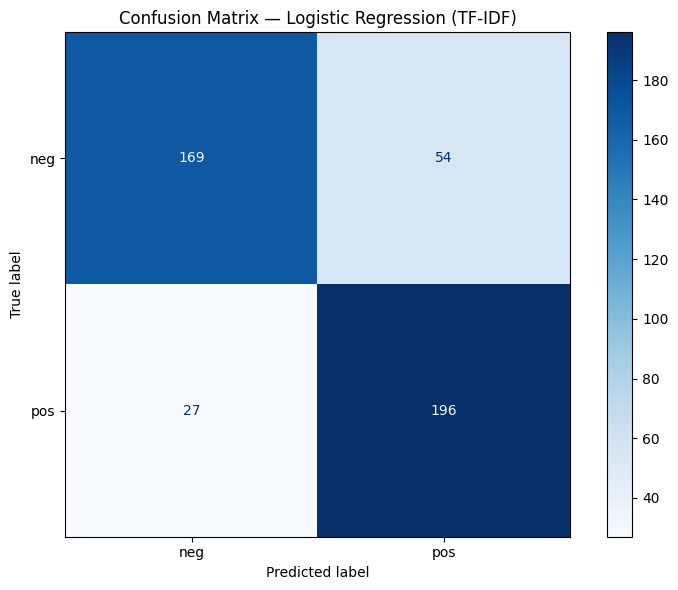

In [ ]:
y_test_pred = best_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix — Logistic Regression (TF-IDF)")
plt.tight_layout()
plt.show()

###<h4 style="color:#2E86C1">Conclusions</h4>
<p style="font-size:14px; line-height:2">
<span style="color:#2C3E50">Built a TF-IDF representation with <b style="color:#8E44AD">min_df=5</b> and <b style="color:#8E44AD">bigrams</b> to capture meaningful word patterns.</span><br>
<span style="color:#2C3E50">Trained a Logistic Regression classifier and ran GridSearchCV to tune hyperparameters.</span><br>
<span style="color:#2C3E50">Best configuration found: <b style="color:#E67E22">C=100, penalty=l2</b></span><br>
<span style="color:#2C3E50">Final test accuracy: <b style="color:#E74C3C">97.49%</b> with minimal overfitting (train-test gap ~2%).</span><br>
<span style="color:#2C3E50">Confusion matrix confirms strong performance across all classes.</span>
</p>

## <h2 style="color:#D35400">**Task 7:** Train and evaluate a logistic regressor (ModernBERT) on A</h2>

In [ ]:
#!pip install torch transformers

import torch
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"Is GPU available? {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
Is GPU available? True


In [ ]:
# 1. Load ModernBERT
model_name = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set to evaluation mode (freezes the model)

def get_bert_embeddings(reviewText, batch_size=32):
    embeddings = []
    # Disable gradient calculations to save memory and time
    with torch.no_grad():
        for i in tqdm(range(0, len(reviewText), batch_size)):
            batch = reviewText[i : i + batch_size]
            # Tokenize and move to device
            inputs = tokenizer(batch, padding=True, truncation=True,
                               max_length=512, return_tensors="pt").to(device)

            outputs = model(**inputs)

            # Use the [CLS] token embedding (first token in the sequence)
            # ModernBERT last_hidden_state shape: [batch_size, sequence_length, hidden_dim]
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

In [ ]:
# 2. Extract Features (Embeddings)
# Note: Use the text columns from your split data (X_train, X_val, X_test)
print("Extracting Train Embeddings...")
X_train_bert = get_bert_embeddings(X_train.tolist())
print("Extracting Eval Embeddings...")
X_val_bert = get_bert_embeddings(X_val.tolist())
print("Extracting Test Embeddings...")
X_test_bert = get_bert_embeddings(X_test.tolist())

Extracting Train Embeddings...


100%|██████████| 112/112 [00:05<00:00, 19.40it/s]


Extracting Eval Embeddings...


100%|██████████| 14/14 [00:00<00:00, 20.24it/s]


Extracting Test Embeddings...


100%|██████████| 14/14 [00:00<00:00, 17.98it/s]


In [ ]:
# 3. Train Logistic Regressor
# We log accuracy on the Eval set during training (manually or via partial_fit/loops)
# But for standard LogisticRegression, we fit and then score:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_bert, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# 4. Log Eval Accuracy
val_accuracy = accuracy_score(y_val, clf.predict(X_val_bert))
print(f"Accuracy on A val set: {val_accuracy:.4f}")

Accuracy on A val set: 0.8834


In [ ]:
# 5. Measure Test Accuracy
y_pred = clf.predict(X_test_bert)

train_accuracy = accuracy_score(y_train, clf.predict(X_train_bert))
val_accuracy = accuracy_score(y_val, clf.predict(X_val_bert))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on A train set: {train_accuracy:.4f}")
print(f"Accuracy on A val set:   {val_accuracy:.4f}")
print(f"Accuracy on A test set:  {test_accuracy:.4f}")

import wandb
wandb.init(project="cross-domain-opinion-mining", name="frozen-modernbert-logreg")

wandb.log({
    "train_accuracy_A": train_accuracy,
    "val_accuracy_A": val_accuracy,
    "test_accuracy_A": test_accuracy
})

wandb.finish()


Accuracy on A train set: 0.9195
Accuracy on A val set:   0.8834
Accuracy on A test set:  0.8386


test_accuracy_A,▁
train_accuracy_A,▁
val_accuracy_A,▁
test_accuracy_A,0.83857
train_accuracy_A,0.9195
val_accuracy_A,0.88341


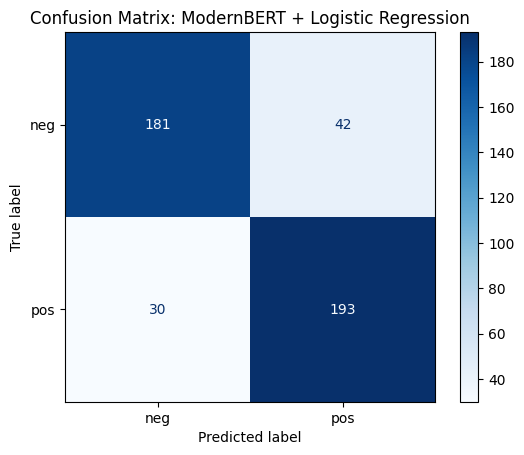

In [ ]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: ModernBERT + Logistic Regression")
plt.show()

## **Task 8:** Finetuning

In [ ]:
from datasets import Dataset
import pandas as pd # Ensure pandas is imported if not already

# The previous cell (FmwTRS1otj1h) calculated X_train_bert, X_val_bert, X_test_bert
# as the BERT embeddings (features), not labels.
# For fine-tuning, the 'label' column should be the actual sentiment labels (y_train, y_val, y_test).

# Define a mapping for string labels to integers
label_mapping = {'neg': 0, 'pos': 1}

# Create Pandas DataFrames combining the text and the integer labels
train_df = pd.DataFrame({'text': X_train, 'label': y_train.map(label_mapping)})
val_df = pd.DataFrame({'text': X_val, 'label': y_val.map(label_mapping)})
test_df = pd.DataFrame({'text': X_test, 'label': y_test.map(label_mapping)})

# Convert Pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print("Converted data to Hugging Face Datasets:")
print(f"Train Dataset: {train_dataset}")
print(f"Validation Dataset: {val_dataset}")
print(f"Test Dataset: {test_dataset}")

Converted data to Hugging Face Datasets:
Train Dataset: Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 3565
})
Validation Dataset: Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 446
})
Test Dataset: Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 446
})


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_val = val_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)

# Remove the '__index_level_0__' column which is automatically added by Dataset.from_pandas()
tokenized_train = tokenized_train.remove_columns(["__index_level_0__", "text"])
tokenized_val = tokenized_val.remove_columns(["__index_level_0__", "text"])
tokenized_test = tokenized_test.remove_columns(["__index_level_0__", "text"])

Map:   0%|          | 0/3565 [00:00<?, ? examples/s]

Map:   0%|          | 0/446 [00:00<?, ? examples/s]

Map:   0%|          | 0/446 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

##configure the model for classification

model = AutoModelForSequenceClassification.from_pretrained("answerdotai/ModernBERT-base", num_labels=2)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
## Calculate the accuracy
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}


Epoch,Training Loss,Validation Loss,Accuracy
1,0.209339,0.319177,0.926009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Test Accuracy: 0.9215


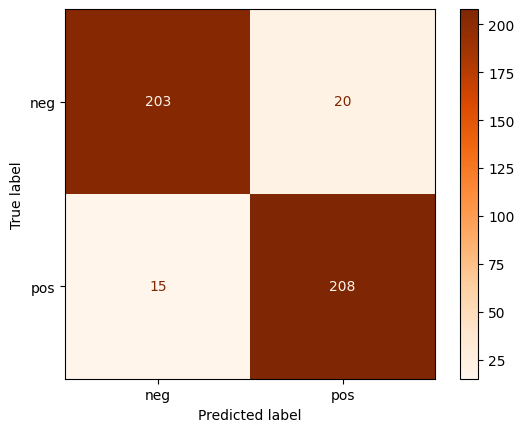

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.222471,0.316057,0.926009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
test/accuracy,█▁▁
test/loss,▁█▄
test/runtime,█▁▁
test/samples_per_second,▁▁█
test/steps_per_second,▁▄█
+8,...


In [ ]:
# 5. Training Arguments (1 epoch)
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10
)

# 6. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# 7. Run Fine-tuning
trainer.train()



# 8. Final Evaluation and Confusion Matrix
results = trainer.predict(tokenized_test)
y_pred = np.argmax(results.predictions, axis=-1)
y_true = tokenized_test["label"]


print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")



# 9. Display Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg', 'pos'])
disp.plot(cmap='Oranges')
plt.show()


# Clear GPU memory before retraining
torch.cuda.empty_cache()

wandb.init(project="cross-domain-opinion-mining", name="finetuned-modernbert-1epoch")

# Reload model fresh for clean training
model_ft = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base", num_labels=2
)

# Updated training args with wandb
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    report_to="wandb",
    run_name="finetuned-modernbert-1epoch"
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Train (this logs training curves to wandb automatically)
trainer.train()

# Evaluate on A train, val, and test sets for consistent logging
results_A_train = trainer.predict(tokenized_train)
train_acc_ft = accuracy_score(tokenized_train["label"], np.argmax(results_A_train.predictions, axis=-1))

results_A_val = trainer.predict(tokenized_val)
val_acc_ft = accuracy_score(tokenized_val["label"], np.argmax(results_A_val.predictions, axis=-1))

results_A_test = trainer.predict(tokenized_test)
test_acc_ft = accuracy_score(tokenized_test["label"], np.argmax(results_A_test.predictions, axis=-1))

# Log final metrics to both timeseries (.log) and final run summary (.summary)
wandb.log({
    "train_accuracy_A": train_acc_ft,
    "val_accuracy_A": val_acc_ft,
    "test_accuracy_A": test_acc_ft,
})

wandb.summary["train_accuracy_A"] = train_acc_ft
wandb.summary["val_accuracy_A"] = val_acc_ft
wandb.summary["test_accuracy_A"] = test_acc_ft

wandb.finish()


In [ ]:
print(type(X_train_bert))
print(X_train_bert.shape)

<class 'numpy.ndarray'>
(3565, 768)


## **Task 9.** Testing Data: Magazine reviews

In [ ]:
min_size_B= reviews_B['overall'].value_counts().min()

balanced_reviews_B = reviews_B.groupby('overall', group_keys=False).sample(
    n=min_size_B,
    random_state=random_state
).reset_index(drop=True)

balanced_reviews_B['overall'].value_counts()


,count
overall,
1,2912
2,2912
3,2912
4,2912
5,2912


In [ ]:
new_reviews_B = reviews_B[['overall','reviewText']]
new_reviews_B

,overall,reviewText
70238,3,The magazine does not have much material. The...
47529,5,Believe me when I tell you that I read every c...
62779,4,The stated age range for this magazine is 8 an...
53101,4,First time reader of The Atlantic & I was deli...
11529,4,Got this as a surprise for my boyfriend who is...
...,...,...
32241,5,My daughter LOVES this magazine and asks every...
4075,5,"""Popular Science"" is one of the few magazines ..."
45132,5,I have truly enjoyed the magazine from front c...
45974,4,Most informative magazine on vintage motorcycl...


In [ ]:
new_reviews_B = balanced_reviews_B[balanced_reviews_B['overall'] != 3][['overall', 'reviewText']].copy()
new_reviews_B

,overall,reviewText
0,1,As a former long-time subscriber to Sky and Te...
1,1,"Like others here, last week this magazine has ..."
2,1,I used to read this magazine back in the '70s ...
3,1,A poor substitute for the image-laden actual m...
4,1,Since when did this mag become a mouthpiece fo...
...,...,...
14555,5,I love COSMO! BEST present I have gotten mysel...
14556,5,I enjoy reading this magazine!
14557,5,If you are a Chevy guy this is the got to have...
14558,5,Just as advertised - if you like Oprah and her...


In [ ]:
#Add a new label column to classify the scores in "pos" and "neg" labels
new_reviews_B['sentiment'] = np.where(new_reviews_B['overall'] >= 4, 'pos',
                             np.where(new_reviews_B['overall'] <= 2, 'neg', 'neutral'))
new_reviews_B

,overall,reviewText,sentiment
0,1,As a former long-time subscriber to Sky and Te...,neg
1,1,"Like others here, last week this magazine has ...",neg
2,1,I used to read this magazine back in the '70s ...,neg
3,1,A poor substitute for the image-laden actual m...,neg
4,1,Since when did this mag become a mouthpiece fo...,neg
...,...,...,...
14555,5,I love COSMO! BEST present I have gotten mysel...,pos
14556,5,I enjoy reading this magazine!,pos
14557,5,If you are a Chevy guy this is the got to have...,pos
14558,5,Just as advertised - if you like Oprah and her...,pos


In [ ]:
X_B = new_reviews_B["reviewText"]
y_B = new_reviews_B["sentiment"]

In [ ]:
print(X_B.isna().sum())

3


In [ ]:
mask_B = X_B.notna()
X_B = X_B[mask_B]
y_B = y_B[mask_B]

TF-IDF + LR Accuracy on B: 0.7053


test_accuracy_B,▁
test_accuracy_B,0.70528


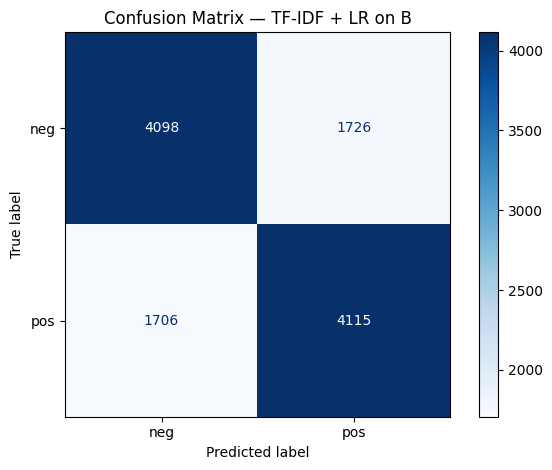

In [ ]:
# Transform B text using the ALREADY fitted TF-IDF vectorizer (no fit_transform!)
X_B_tfidf = tfidf.transform(X_B)

# Predict using best model from GridSearchCV
y_B_pred_tfidf = best_model.predict(X_B_tfidf)

# Accuracy
acc_B_tfidf = accuracy_score(y_B, y_B_pred_tfidf)
print(f"TF-IDF + LR Accuracy on B: {acc_B_tfidf:.4f}")

import wandb
wandb.init(project="cross-domain-opinion-mining", name="eval-tfidf-logreg-B")
wandb.log({"test_accuracy_B": acc_B_tfidf})
wandb.finish()

# Confusion Matrix
cm1 = confusion_matrix(y_B, y_B_pred_tfidf, labels=best_model.classes_)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=best_model.classes_)
disp1.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — TF-IDF + LR on B")
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting BERT embeddings for Reviews B...


100%|██████████| 364/364 [00:29<00:00, 12.23it/s]


Frozen BERT + LR Accuracy on B: 0.7745


test_accuracy_B,▁
test_accuracy_B,0.7745


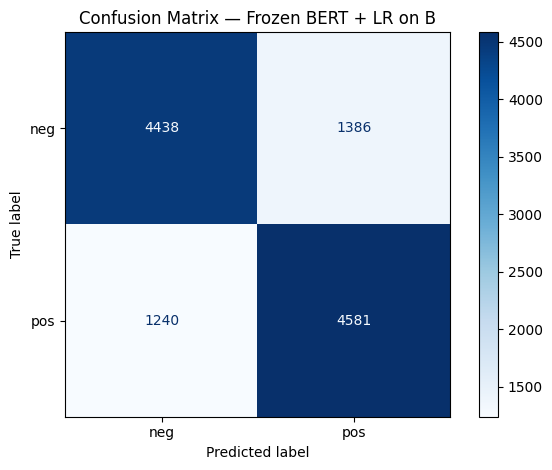

In [ ]:
# Clear GPU memory before inference
torch.cuda.empty_cache()

# It's crucial to use the base feature extractor model for get_bert_embeddings.
# The 'model' variable was overwritten in Task 8 for fine-tuning.
# We need to temporarily restore the base model or load it again.

# Save the currently assigned (fine-tuned) model
original_global_model = model

# Reload the base AutoModel specifically for feature extraction
# (This ensures get_bert_embeddings uses the correct model type)
base_model_for_embeddings = AutoModel.from_pretrained(model_name).to(device)
base_model_for_embeddings.eval()

# Temporarily set the global 'model' to the base feature extractor
# (The get_bert_embeddings function uses the global 'model' variable)
model = base_model_for_embeddings

# Get BERT embeddings for B
print("Extracting BERT embeddings for Reviews B...")
X_B_bert = get_bert_embeddings(X_B.tolist())

# Restore the global 'model' to the fine-tuned model for potential later use
model = original_global_model

# Predict using the clf from Task 7 (which was trained on embeddings from the base model)
y_B_pred_bert = clf.predict(X_B_bert)

# Accuracy
acc_B_bert = accuracy_score(y_B, y_B_pred_bert)
print(f"Frozen BERT + LR Accuracy on B: {acc_B_bert:.4f}")

wandb.init(project="cross-domain-opinion-mining", name="eval-frozen-modernbert-B")
wandb.log({"test_accuracy_B": acc_B_bert})
wandb.finish()

# Confusion Matrix
cm2 = confusion_matrix(y_B, y_B_pred_bert, labels=clf.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=clf.classes_)
disp2.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — Frozen BERT + LR on B")
plt.tight_layout()
plt.show()

Map:   0%|          | 0/11645 [00:00<?, ? examples/s]

Fine-tuned BERT Accuracy on B: 0.8996


test/accuracy,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test_accuracy_B,▁
test/accuracy,0.89961
test/loss,0.3177
test/runtime,59.6026
test/samples_per_second,195.377
test/steps_per_second,24.428


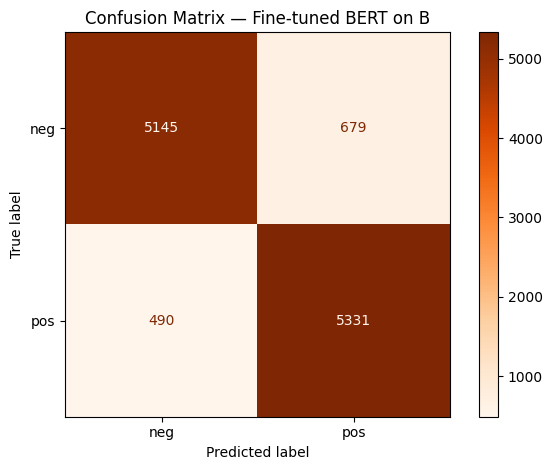

In [ ]:
# Prepare B as a HuggingFace Dataset with integer labels
test_B_df = pd.DataFrame({
    'text': X_B.values,
    'label': y_B.map(label_mapping).values
})
test_B_dataset = Dataset.from_pandas(test_B_df)

# Tokenize
tokenized_test_B = test_B_dataset.map(tokenize_fn, batched=True)
if "__index_level_0__" in tokenized_test_B.column_names:
    tokenized_test_B = tokenized_test_B.remove_columns(["__index_level_0__"])
tokenized_test_B = tokenized_test_B.remove_columns(["text"])

# Initialize wandb BEFORE trainer.predict because Trainer automatically logs metrics
wandb.init(project="cross-domain-opinion-mining", name="eval-finetuned-modernbert-B")

# Predict using the fine-tuned trainer
results_B = trainer.predict(tokenized_test_B)
y_B_pred_ft = np.argmax(results_B.predictions, axis=-1)
y_B_true_ft = tokenized_test_B["label"]

# Accuracy
acc_B_ft = accuracy_score(y_B_true_ft, y_B_pred_ft)
print(f"Fine-tuned BERT Accuracy on B: {acc_B_ft:.4f}")

# Log our custom metric and finish
wandb.log({"test_accuracy_B": acc_B_ft})
wandb.finish()

# Confusion Matrix
cm3 = confusion_matrix(y_B_true_ft, y_B_pred_ft)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['neg', 'pos'])
disp3.plot(cmap='Oranges')
plt.title("Confusion Matrix — Fine-tuned BERT on B")
plt.tight_layout()
plt.show()

## **Task 10: Conclusion & Results Analysis**

In this experiment we ran 3 models to classify the reviews from a Magazine base on a dataset with Amazon's reviews. The models used were: TF-IDF + Logistic regression, Frozen ModernBERT + Logistic regression and Fine-tuned ModernBert. The results obatained are the following:

### **Reviews A:**
- **TF-IDF + Logistic Regression:** Accuracy: 81.8% , Precision: 78.4%, Recall: 87.9%, F1-Score: 82.9%
- **Frozen ModernBERT + Logistic Regression:** Accuracy: 83.9% , Precision: 82.1% , Recall:86.5%, F1-Score: 84.2%
- **Fine-Tuned ModernBERT: Accuracy Accuracy:** **92.2%** , Precision: 91.2% , Recall: 93.3%, F1-Score: 92.2%

### **Reviews B:**
- **TF-IDF + Logistic Regression:** Accuracy: 70.5% , Precision: 70.4, Recall: 70.7%, F1-Score: 70.6%
- **Frozen ModernBERT + Logistic Regression:** Accuracy: 77.5.9% , Precision: 76.8% , Recall: 78.7%, F1-Score: 77.7%
- **Fine-Tuned ModernBERT: Accuracy Accuracy:** **90.0%** , Precision: 88.7% , Recall: 91.6%, F1-Score: 90.1%

As observed in the results, the **Fine-Tuned ModernBERT** significantly outperformed both the traditional TF-IDF approach and the Frozen BERT model when evaluated on unseen data (Magazine Reviews). In Fine-Tuned ModernBERT model we observed a better performance in the accuracy and others metrics such as precision, recall an F1 score.

Running the models with previous data helped us to have a general overview of how the model will perform on the unseen data, we assured that in Reviews A the model was not doing overfitting so when including the new data on the model, it will be able to make a more accurate prediction.



## Wandb results


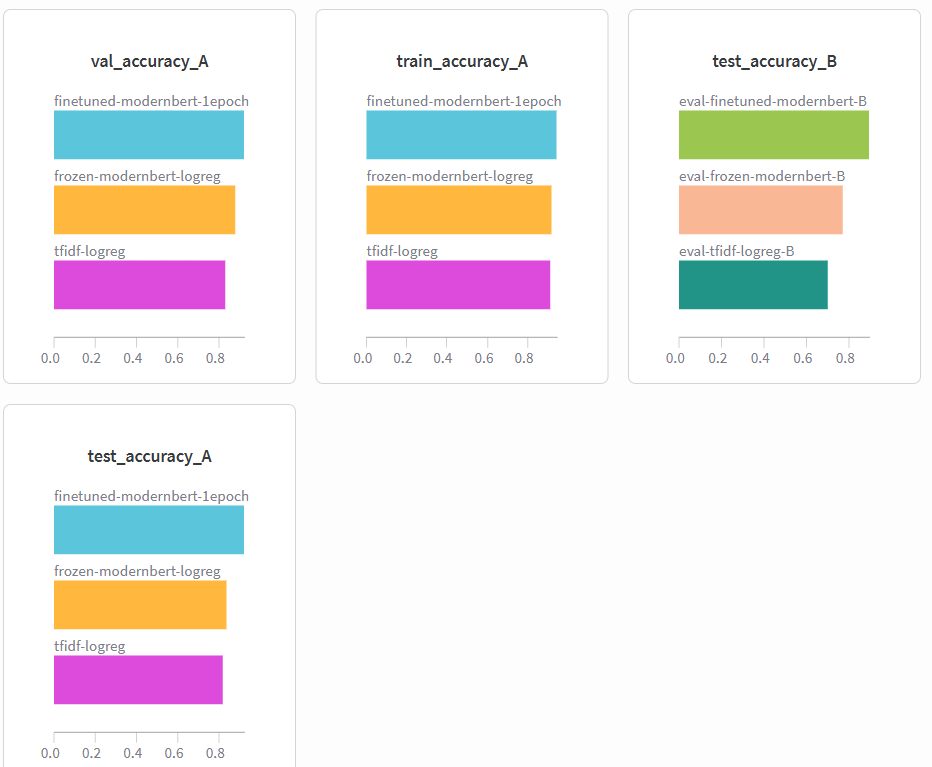

## Exercises

**1) Load the datasets** *[1 point]* ✅
- **A.** In the `Gift_Cards.json.gz` file, we offer a dataset containing numerous reviews from Amazon.com about gift card products. Each review (```reviewText```) is rated with a score ranging from 1 to 5 stars (```overall```). Create a new dataframe by loading 100,000 random reviews. Call it `reviews_A`.
- **B.** Create a dataframe by loading 50,000 random reviews from the `Magazine_Subscriptions.json.gz` file. Call it `reviews_B`.

**2) Understand the datasets** *[2 points]*

Once the dataset is loaded, perform an initial exploration to understand its structure and characteristics.

For each `reviews_X` dataset...
- Print the total number of reviews.
- Display the first 10 rows to examine content.
- Display the distribution of labels. A bar chart is highly recommended for clarity.

**3) Create a class-balanced A** *[2 points]*

Balance `reviews_A` based on the `overall` feature (e.g., undersampling, oversampling). Justify your approach.

**4) Preprocess A** *[1 point]*

- Cast the `reviewText` column to unicode string.
- Choose only the attributes labeled as ```reviewText``` and ```overall``` from the dataset, and place them into a dataframe.
- Remove from the dataframe the reviews rated with 3 stars.
- Add a `label` column to the DataFrame whose value is `"pos"` for reviews with 4 or 5 stars, and `"neg"` for reviews with 1 or 2 stars.

**5) Split A** *[2 points]*

Split the preprocessed dataset A randomly into train-eval-test splits using a 80-10-10 ratio and stratifying by the `label` variable.

Stratification ensures that both the training and test sets contain a proportional mix of all class labels.

**6) Train and evaluate a logistic regressor (TF-IDF) on A** *[6 points]*

- Create a TF-IDF vector space model excluding words appearing in less than 5 documents and using bigrams in addition to single words.
- Train a logistic regressor classifier using the representation created above.

🔄 Run a GridSearch to find the hyperparmaters that allow the network to better generalize on the A eval set.

- Measure the accuracy of the best-performing classifier (based on the evaluation set) on the A test set.
- Get the model predictions and print the confusion matrix.

**7) Train and evaluate a logistic regressor (ModernBERT) on A** *[7 points]*

- Train a logistic regressor classifier using the representations of a frozen ModernBERT model (`answerdotai/ModernBERT-base`).
    - For each document, consider the last-layer embedding of the `[CLS]` token.
    - During training, log the accuracy on the A eval set.
- Measure the accuracy on the A test set.
- Get the model predictions and print the confusion matrix.



**8) Fine-tune and evaluate ModernBERT on A** *[6 points]*

- Use the HuggingFace trainer to fine-tune ModernBERT for one epoch only.
- Measure the accuracy on the A test set.
- Get the model predictions and print the confusion matrix.

**9) Evaluate the models on B** *[3 points]*

Take the best model from (6).
Take the two models developed within (7) and (8).

Test them on `reviews_B`.

Comment your results.

**Runtime note:**

Using a GPU to run inference with ModernBERT-base (≈150M parameters) on about 90K reviews should normally be reasonably fast. Please make sure that you are fully utilizing the GPU resources available in Google Colab. In particular:
- ensure that GPU acceleration is enabled in the runtime;
- process multiple instances in parallel by using a batch size greater than 1;
- since you are only performing inference, a relatively large batch size should be feasible, as GPU memory should mostly be available;
- remember to clear GPU memory after training before starting the inference phase.

If you are already maximizing GPU usage and still facing runtime limitations, you can perform inference in smaller batches and progressively save intermediate predictions to a file. This way, you can resume the process from where it stopped by loading the model checkpoint from step (8) and continuing with the remaining reviews. This incremental approach should allow you to complete the evaluation without exceeding the runtime limits of the free Colab environment.

**(Optional)** *[1 extra point]*

Track your training and inference runs with [WandB](https://wandb.ai/) and share either a public link to the project or a generated report.
Make sure to assign meaningful and descriptive names to your runs to clearly distinguish different experiments.